# Credit Card Fraud Detection Using Machine Learning

## Project Category
Classification / Anomaly Detection

---

## Objective

The objective of this project is to detect fraudulent credit card transactions using machine learning techniques.

This project aims to:
- analyze transaction patterns,
- identify fraudulent activities,
- handle imbalanced datasets,
- apply classification algorithms,
- evaluate fraud detection performance.

---

## Dataset Information

The dataset contains credit card transactions labeled as:

- Legitimate Transactions
- Fraudulent Transactions

The dataset includes anonymized numerical features extracted from real transaction data.
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?
---

## Algorithms and Techniques Used

- Logistic Regression
- Random Forest
- XGBoost
- SMOTE
- Confusion Matrix
- Classification Report

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

---

## Project Workflow

1. Data Understanding
2. Data Cleaning
3. Imbalanced Data Analysis
4. SMOTE Oversampling
5. Model Training
6. Model Evaluation
7. Fraud Detection Analysis
8. Conclusion

In [1]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [2]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (284807, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0

In [4]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [11]:
### inbalanced data set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [12]:
### SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

In [13]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    227451
1    227451
Name: count, dtype: int64


In [14]:
### Model Training

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [15]:
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score)

import pandas as pd

In [22]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear" ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1 )}

In [23]:
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.975545,0.061017,0.918367,0.114431
1,Random Forest,0.998912,0.638462,0.846939,0.728070


In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1)

In [25]:
xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=-1,
              num_parallel_tree=None, ...)

In [26]:
y_pred_xgb = xgb_model.predict(X_test)

In [27]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("Precision:",
      precision_score(y_test, y_pred_xgb))

print("Recall:",
      recall_score(y_test, y_pred_xgb))

print("F1 Score:",
      f1_score(y_test, y_pred_xgb))

Accuracy: 0.9995435553526912
Precision: 0.8913043478260869
Recall: 0.8367346938775511
F1 Score: 0.8631578947368421


In [28]:
results = []

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear"),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=50,
            max_depth=8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1 ),

    "XGBoost":
        XGBClassifier(
            n_estimators=50,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1 )}

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(y_test, y_pred),

        "Recall":
            recall_score(y_test, y_pred),

        "F1 Score":
            f1_score(y_test, y_pred)})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.975545,0.061017,0.918367,0.114431
1,Random Forest,0.998912,0.638462,0.846939,0.728070
2,XGBoost,0.999544,0.891304,0.836735,0.863158


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

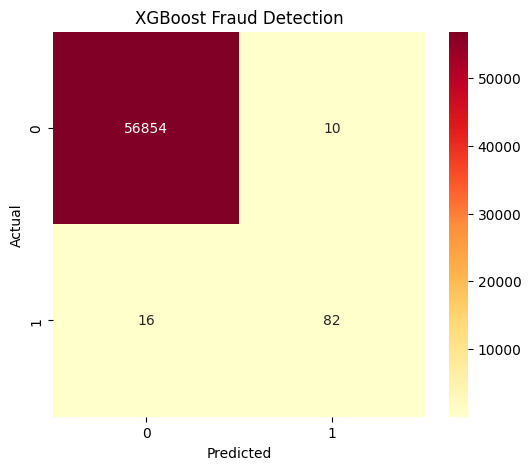

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("XGBoost Fraud Detection")

plt.show()

The confusion matrix demonstrates that the XGBoost model achieved highly effective fraud detection performance. Due to the large dataset size and computational cost, SMOTE oversampling significantly slowed down model training, so class weighting techniques were preferred for the final models.

### Results

- 56,854 normal transactions were correctly classified.
- Only 10 normal transactions were incorrectly flagged as fraud.
- 82 fraudulent transactions were successfully detected.
- Only 16 fraud cases were missed.

### Interpretation

The model maintained:
- extremely low false positive rates,
- strong fraud detection capability,
- and highly balanced classification performance.

The results indicate that the XGBoost algorithm effectively learned fraudulent transaction patterns while minimizing unnecessary fraud alerts for legitimate customers.